In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

## Load Data set

In [4]:
df = pd.read_csv("../data/processed/itsm_incident_clean.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Dataset Shape: (100000, 26)

Columns:
 Index(['Status', 'Ticket ID', 'Priority', 'Source', 'Topic', 'Agent Group',
       'Agent Name', 'Created time', 'Expected SLA to resolve',
       'Expected SLA to first response', 'First response time',
       'SLA For first response', 'Resolution time', 'SLA For Resolution',
       'Close time', 'Agent interactions', 'Survey results', 'Product group',
       'Support Level', 'Country', 'Latitude', 'Longitude', 'created_hour',
       'created_day_of_week', 'created_month', 'resolution_duration_hours'],
      dtype='object')

Data Types:
 Status                             object
Ticket ID                          object
Priority                           object
Source                             object
Topic                              object
Agent Group                        object
Agent Name                         object
Created time                       object
Expected SLA to resolve            object
Expected SLA to first response     obj

## Ticket Demand by Hour


Tickets by Hour:
 created_hour
10.0    4211
11.0    4214
12.0    4173
13.0    4119
14.0    4178
15.0    4135
16.0    4073
17.0    4188
18.0    4211
19.0    4169
20.0    4168
21.0    4137
22.0    4201
23.0    4198
Name: count, dtype: int64


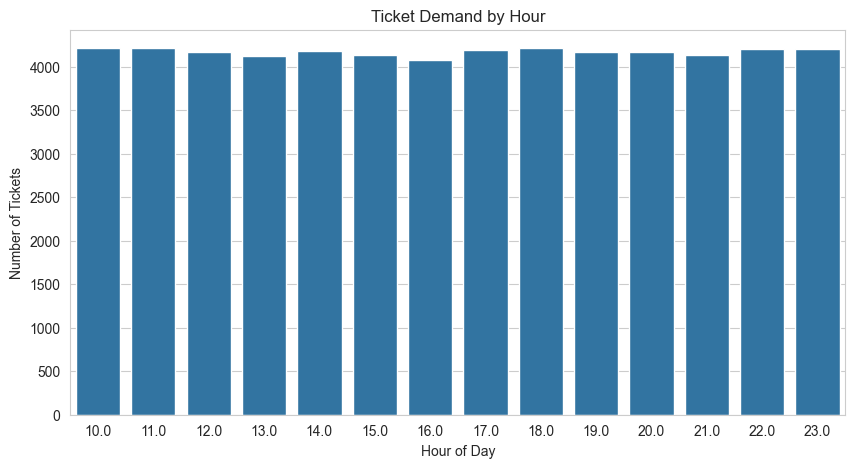

In [5]:
tickets_by_hour = df['created_hour'].value_counts().sort_index()

print("\nTickets by Hour:\n", tickets_by_hour)

plt.figure(figsize=(10,5))
sns.barplot(x=tickets_by_hour.index, y=tickets_by_hour.values)
plt.title("Ticket Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Tickets")
plt.show()


## Ticket Demand by Day of Week


Tickets by Day of Week:
 created_day_of_week
Monday       8312
Tuesday      8373
Wednesday    8325
Thursday     8369
Friday       8435
Saturday     8338
Sunday       8223
Name: count, dtype: int64


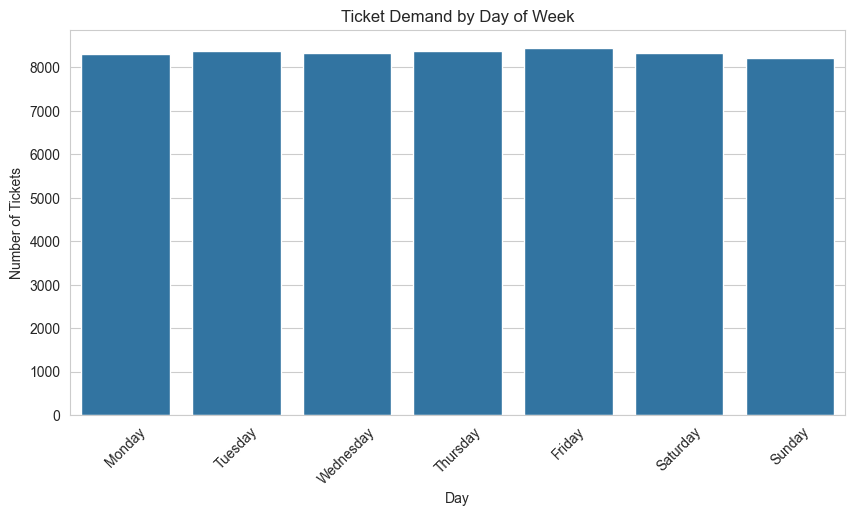

In [6]:
day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

tickets_by_day = df['created_day_of_week'].value_counts().reindex(day_order)

print("\nTickets by Day of Week:\n", tickets_by_day)

plt.figure(figsize=(10,5))
sns.barplot(x=tickets_by_day.index, y=tickets_by_day.values)
plt.title("Ticket Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

##  Monthly Ticket Trends


Tickets by Month:
 created_month
4.0    13110
5.0    13747
6.0    13158
7.0    13480
8.0     4880
Name: count, dtype: int64


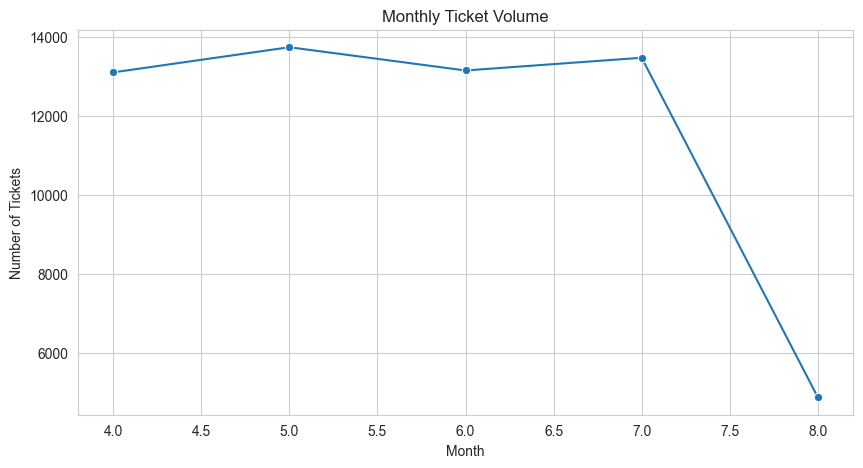

In [7]:
tickets_by_month = df['created_month'].value_counts().sort_index()

print("\nTickets by Month:\n", tickets_by_month)

plt.figure(figsize=(10,5))
sns.lineplot(x=tickets_by_month.index, y=tickets_by_month.values, marker="o")
plt.title("Monthly Ticket Volume")
plt.xlabel("Month")
plt.ylabel("Number of Tickets")
plt.show()


## Ticket Category Analysis


Ticket Distribution by Topic:
 Topic
General Inquiry     20254
Network Issue       20053
Hardware Failure    20027
Access Request      19923
Software Bug        19743
Name: count, dtype: int64


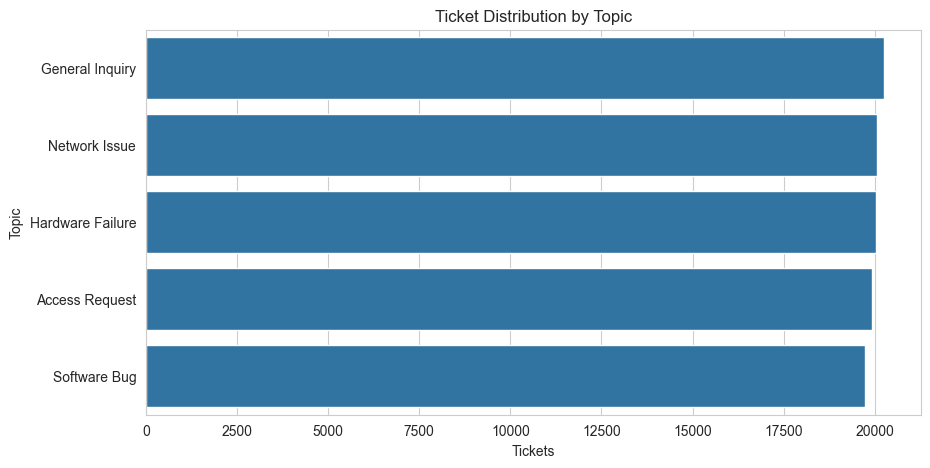


Ticket Distribution by Product Group:
 Product group
Hardware    25087
Cloud       25029
Network     25023
Software    24861
Name: count, dtype: int64


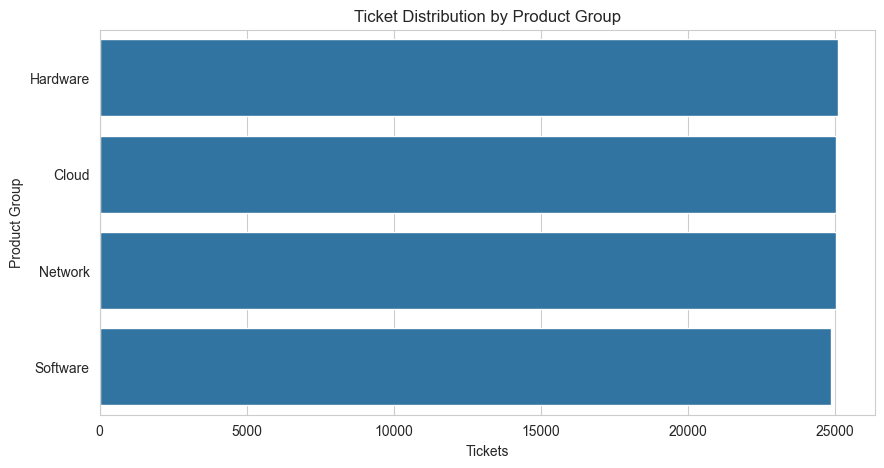

In [13]:
topic_counts = df['Topic'].value_counts()

print("\nTicket Distribution by Topic:\n", topic_counts)

plt.figure(figsize=(10,5))
sns.barplot(x=topic_counts.values, y=topic_counts.index)
plt.title("Ticket Distribution by Topic")
plt.xlabel("Tickets")
plt.ylabel("Topic")
plt.show()


product_counts = df['Product group'].value_counts()

print("\nTicket Distribution by Product Group:\n", product_counts)

plt.figure(figsize=(10,5))
sns.barplot(x=product_counts.values, y=product_counts.index)
plt.title("Ticket Distribution by Product Group")
plt.xlabel("Tickets")
plt.ylabel("Product Group")
plt.show()

## Agent Workload


Top 10 Agents by Ticket Volume:
 Agent Name
Mohammed Al-Hamdan     1491
Khalid Al-Sabah        1483
Abdullah Al-Farsi      1461
Fahad Al-Nasser        1451
Mohammed Al-Khalifa    1447
Fahad Al-Mansoori      1445
Yousef Al-Salem        1444
Khalid Al-Nasser       1435
Fahad Al-Hamdan        1427
Yousef Al-Nasser       1426
Name: count, dtype: int64


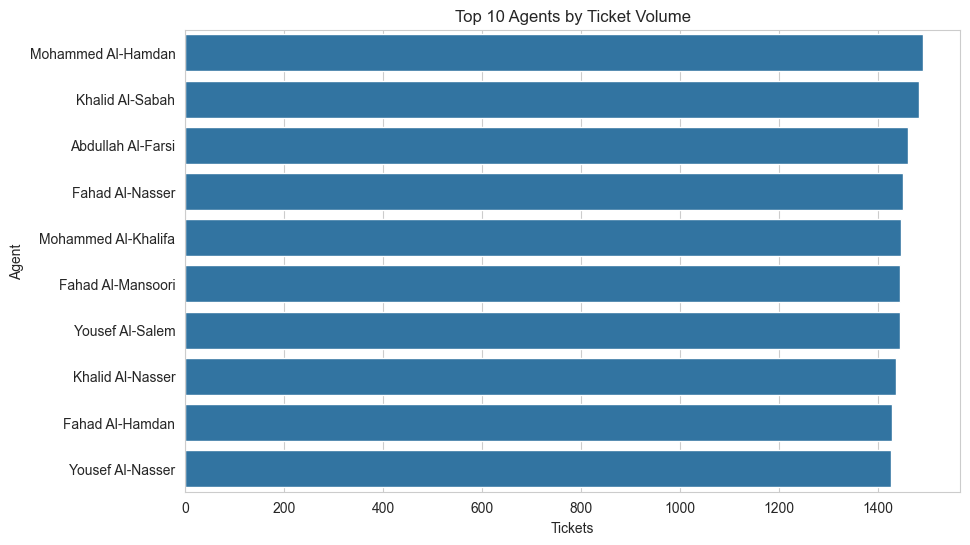


Tickets by Agent Group:
 Agent Group
Development         20158
Network Ops         20144
Security            19985
Customer Service    19884
IT Support          19829
Name: count, dtype: int64


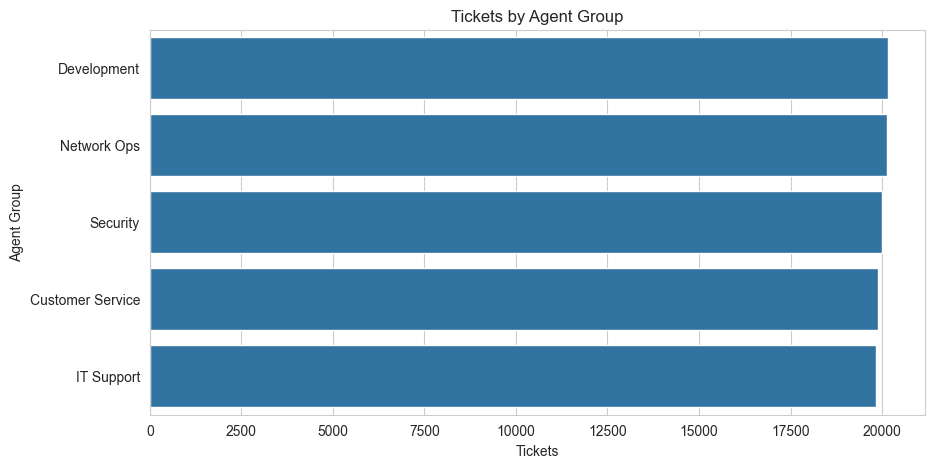

In [15]:
agent_counts = df['Agent Name'].value_counts().head(10)

print("\nTop 10 Agents by Ticket Volume:\n", agent_counts)

plt.figure(figsize=(10,6))
sns.barplot(x=agent_counts.values, y=agent_counts.index)
plt.title("Top 10 Agents by Ticket Volume")
plt.xlabel("Tickets")
plt.ylabel("Agent")
plt.show()


agent_group_counts = df['Agent Group'].value_counts()

print("\nTickets by Agent Group:\n", agent_group_counts)

plt.figure(figsize=(10,5))
sns.barplot(x=agent_group_counts.values, y=agent_group_counts.index)
plt.title("Tickets by Agent Group")
plt.xlabel("Tickets")
plt.ylabel("Agent Group")
plt.show()

## Resolution Duration Analysis


Resolution Duration Statistics:
count    48584.000000
mean         2.223044
std          1.119226
min          0.666667
25%          0.966667
50%          1.950000
75%          2.966667
max          4.000000
Name: resolution_duration_hours, dtype: float64


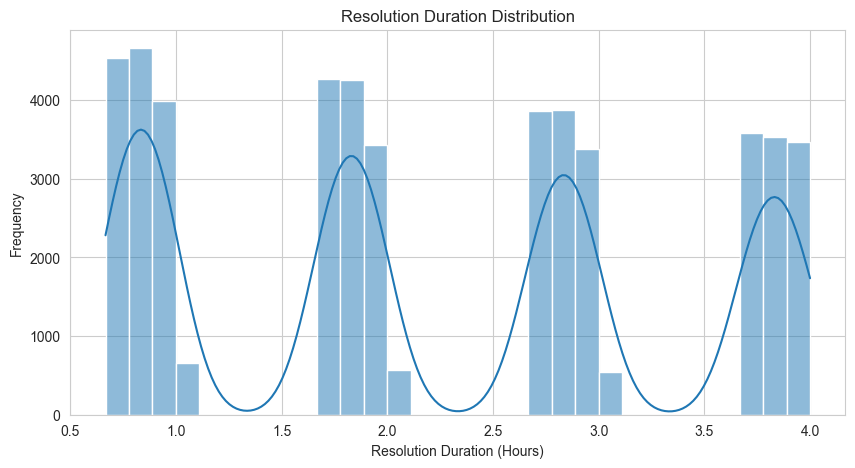

In [16]:
print("\nResolution Duration Statistics:")
print(df['resolution_duration_hours'].describe())

plt.figure(figsize=(10,5))
sns.histplot(df['resolution_duration_hours'], bins=30, kde=True)
plt.title("Resolution Duration Distribution")
plt.xlabel("Resolution Duration (Hours)")
plt.ylabel("Frequency")
plt.show()


## Boxplot for Outliers

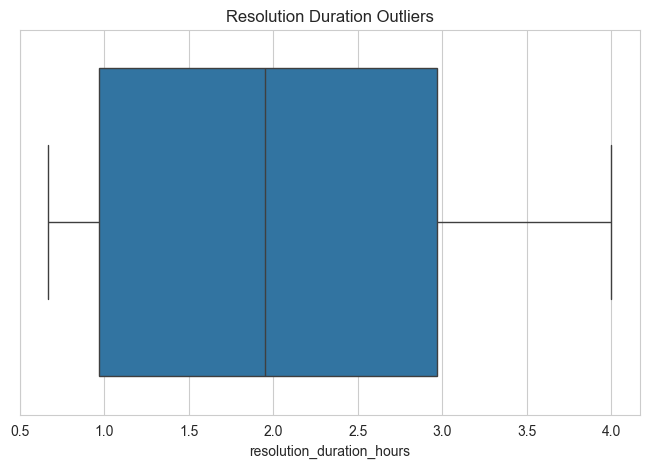

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['resolution_duration_hours'])
plt.title("Resolution Duration Outliers")
plt.show()